In [57]:
#импорт библиотек
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные моделиё
from sklearn import tree #деревья решений
from sklearn import ensemble #ансамбли
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #сплитование выборки
from sklearn.preprocessing import MinMaxScaler



In [2]:
data1 = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/_train_sem09 (1).csv')
data1

,Activity,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D1767,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776
0,1,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,...,0,0,0,0,0,0,0,0,0,0
1,1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,...,1,1,1,1,0,1,0,0,1,0
2,1,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,...,0,0,0,0,0,0,0,0,0,0
3,1,0.000000,0.538825,0.00,0.5,0.196344,0.724230,0.235606,0.288764,0.805110,...,0,0,0,0,0,0,0,0,0,0
4,0,0.100000,0.517794,0.00,0.0,0.494734,0.781422,0.154361,0.303809,0.812646,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3746,1,0.033300,0.506409,0.10,0.0,0.209887,0.633426,0.297659,0.376124,0.727093,...,0,0,0,0,0,0,0,0,0,0
3747,1,0.133333,0.651023,0.15,0.0,0.151154,0.766505,0.170876,0.404546,0.787935,...,0,0,1,0,1,0,1,0,0,0
3748,0,0.200000,0.520564,0.00,0.0,0.179949,0.768785,0.177341,0.471179,0.872241,...,0,0,0,0,0,0,0,0,0,0
3749,1,0.100000,0.765646,0.00,0.0,0.536954,0.634936,0.342713,0.447162,0.672689,...,0,0,0,0,0,0,0,0,0,0


Проверка на пропуски

In [3]:
data1.isnull().sum()
# data.describe(include='object') - нету 
types = data1.dtypes
cat_features = list(types[(types == 'object')].index)
cat_features

[]

Проверка на сбалансировасть 

Целевой признак - Activity

<Axes: xlabel='Activity', ylabel='count'>

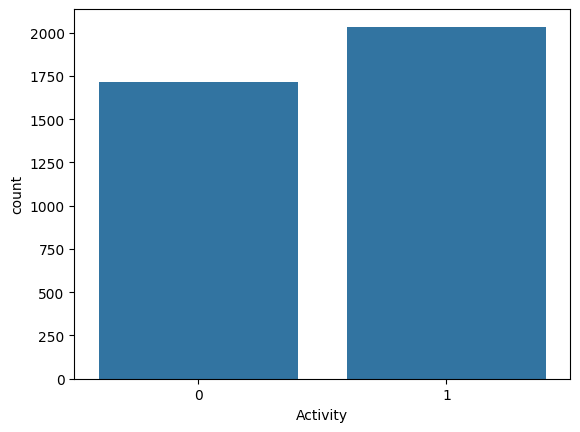

In [4]:
sns.countplot(data=data1, x='Activity')

Узнал на днях о pipeline, которая слегка упращает написание кода, решил применить попробовать.

Оцениваем мультиколинеарность и взаимосвязь с целевым признаком.
- plt.figure(figsize = (10, 5))
- sns.heatmap(data.corr(numeric_only=True), annot = True); 
Долго модулируется

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Создаем pipeline: Шаг 1 -> Шаг 2
pipe = Pipeline([
    ('scaler', StandardScaler()),        # опционально: масштабируем данные
    ('pca', PCA()),                      # этап уменьшения размерности
    ('classifier', RandomForestClassifier(random_state=42))  # модель
])

Создаем матрицу наблюдений $X$ и вектор ответов $y$

In [12]:
X = data1.drop(['Activity'], axis=1)
y = data1['Activity']

## RandomForestClassifier и GridSearchCV

In [21]:
from sklearn.model_selection import GridSearchCV


# Задаем сетку параметров
param_grid = {
    'pca__n_components': [2, 3, 4],           # перебираем количество компонент PCA
    'classifier__n_estimators': [100, 200],    # параметры классификатора
    'classifier__max_depth': [5, 10, None],
}

# Создаем GridSearchCV
grid_search = GridSearchCV(
    pipe,                   # наш pipeline
    param_grid,             # сетка параметров
    cv=5,                   # 5-фолдовая кросс-валидация
    scoring='accuracy',     # метрика (можно изменить на f1, roc_auc и т.д.)
    n_jobs=-1,              # использовать все ядра процессора
    verbose=1               # вывод прогресса
)

# Запускаем поиск
grid_search.fit(X, y)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10, ...], 'classifier__n_estimators': [100, 200], 'pca__n_components': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [22]:
# Лучшие параметры
print("Лучшие параметры:", grid_search.best_params_)
print("Лучшая точность:", grid_search.best_score_)

# Лучшая модель (уже обученная)
best_model = grid_search.best_estimator_

# Можно посмотреть важность компонент PCA в лучшей модели
if 'pca' in best_model.named_steps:
    pca_model = best_model.named_steps['pca']
    print(f"Выбрано компонент PCA: {pca_model.n_components_}")
    print("Объясненная дисперсия:", pca_model.explained_variance_ratio_.sum())

Лучшие параметры: {'classifier__max_depth': 10, 'classifier__n_estimators': 100, 'pca__n_components': 4}
Лучшая точность: 0.6374324012427873
Выбрано компонент PCA: 4
Объясненная дисперсия: 0.23675135196539657


Разделяем выборку на тренировочную и тестовую в соотношении 80/20. Для сохранения соотношений целевого признака используем параметр stratify (стратифицированное разбиение).

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 1, test_size = 0.2)

Точность модели: 78.96%

Топ-5 важных признаков:
1. Признак 26: 3.993%
2. Признак 468: 1.113%
3. Признак 105: 1.079%
4. Признак 13: 0.848%
5. Признак 65: 0.833%

Текущие параметры: n_estimators=200


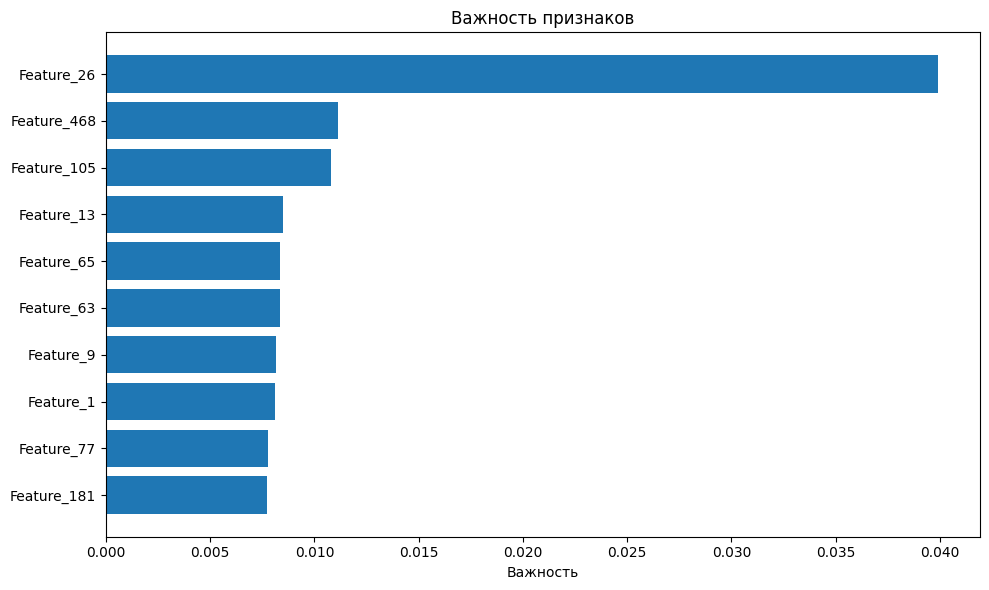

In [35]:
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=200,           
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=42,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None
)

# Обучение модели
model.fit(X_train, y_train)

# predict - предсказание классов
y_pred = model.predict(X_test)

# predict_proba - вероятности принадлежности к классам
y_proba = model.predict_proba(X_test)

#  ОЦЕНКА МОДЕЛИ
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.2%}")

# feature_importances_ - важность признаков
importances = model.feature_importances_
n_features = len(importances)  # количество признаков

# Выводим все признаки или топ-5
top_n = min(5, n_features)  # на случай, если признаков меньше 5
# Сортируем признаки по важности
indices = np.argsort(importances)[::-1]

# Выводим топ-5 отсортированных признаков
print("\nТоп-5 важных признаков:")
for i in range(top_n):
    idx = indices[i]
    print(f"{i+1}. Признак {idx}: {importances[idx]:.3%}")

# get_params - получение параметров модели
params = model.get_params()
print(f"\nТекущие параметры: n_estimators={params['n_estimators']}")
feature_names = [f'Feature_{i}' for i in range(n_features)]
# Визуализация
plt.figure(figsize=(10, 6))
plt.title("Важность признаков")
# Берем топ-10 признаков для визуализации (или все, если меньше 10)
n_show = min(10, n_features)
plt.barh(range(n_show), importances[indices[:n_show]])
plt.yticks(range(n_show), [feature_names[idx] for idx in indices[:n_show]])
plt.xlabel("Важность")
plt.gca().invert_yaxis()  # Самые важные сверху
plt.tight_layout()
plt.show()



Анализ для f1_score

In [36]:
from sklearn.metrics import f1_score

# Для многоклассовой классификации укажите average
f1_micro = f1_score(y_test, y_pred, average='micro')    # микро-усреднение
f1_macro = f1_score(y_test, y_pred, average='macro')    # макро-усреднение
f1_weighted = f1_score(y_test, y_pred, average='weighted')  # взвешенное

print(f"F1 micro: {f1_micro:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 weighted: {f1_weighted:.4f}")

F1 micro: 0.7896
F1 macro: 0.7865
F1 weighted: 0.7886


## RandomForestClassifier и optina

In [37]:
scaler = preprocessing.MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
import optuna
from sklearn import ensemble, metrics
import numpy as np

def optuna_rf(trial):
    # задаем пространства поиска гиперпараметров
    n_estimators = trial.suggest_int('n_estimators', 100, 300, 10)
    max_depth = trial.suggest_int('max_depth', 3, 7, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 15, 40, 1)
    
    # Дополнительные параметры можно добавить:
    # min_samples_split = trial.suggest_int('min_samples_split', 2, 20, 1)
    # max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    # создаем модель
    model = ensemble.RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        random_state=42,  # Убедитесь, что random_state определен
        n_jobs=-1  # для ускорения (использует все ядра)
    )
    
    # обучаем модель
    model.fit(X_train_scaled, y_train)
    
    # Оценка модели (лучше использовать кросс-валидацию или валидационную выборку)
    score = metrics.f1_score(y_train, model.predict(X_train_scaled))
    
    return score

# Или лучше с кросс-валидацией:
def optuna_rf_cv(trial):
    from sklearn.model_selection import cross_val_score
    
    # задаем пространства поиска гиперпараметров
    n_estimators = trial.suggest_int('n_estimators', 100, 300, 10)
    max_depth = trial.suggest_int('max_depth', 3, 10, 1)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20, 1)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20, 1)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    
    # создаем модель
    model = ensemble.RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    
    # Используем кросс-валидацию для более надежной оценки
    scores = cross_val_score(
        model, 
        X_train_scaled, 
        y_train, 
        cv=5,  # 5-кратная кросс-валидация
        scoring='f1',
        n_jobs=-1
    )
    
    # Возвращаем средний F1-score
    return scores.mean()

In [43]:
%%time
# cоздаем объект исследования
# можем напрямую указать, что нам необходимо максимизировать метрику direction="maximize"
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize", )
# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=20)

[I 2025-12-21 23:23:48,301] A new study created in memory with name: RandomForestClassifier
C:\Users\Admin\AppData\Local\Temp\ipykernel_18048\3997592488.py:7: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  n_estimators = trial.suggest_int('n_estimators', 100, 300, 10)
C:\Users\Admin\AppData\Local\Temp\ipykernel_18048\3997592488.py:8: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the

CPU times: total: 39.7 s
Wall time: 13.4 s


Анализ для f1_score

In [46]:
# выводим результаты на обучающей выборке
print("Наилучшие значения гиперпараметров {}".format(study.best_params))
print("f1_score на обучающем наборе: {:.2f}".format(study.best_value))

Наилучшие значения гиперпараметров {'n_estimators': 130, 'max_depth': 7, 'min_samples_leaf': 15}
f1_score на обучающем наборе: 0.84


## LogisticRegression и RandomizedSearchCV

In [47]:
#Создаем объект класса логистическая регрессия
log_reg = linear_model.LogisticRegression(max_iter = 1000)
#Обучаем модель, минимизируя logloss
log_reg.fit(X_train_scaled, y_train)
print("accuracy на тестовом наборе: {:.2f}".format(log_reg.score(X_test_scaled, y_test)))
y_test_pred = log_reg.predict(X_test_scaled)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

accuracy на тестовом наборе: 0.75
f1_score на тестовом наборе: 0.78


In [51]:
from sklearn.model_selection import RandomizedSearchCV


param_distributions = {'penalty': ['l2', 'none'] ,
              'solver': ['lbfgs', 'sag'],
               'C': list(np.linspace(0.01, 1, 10, dtype=float))}
            
random_search = RandomizedSearchCV(
    estimator=linear_model.LogisticRegression(random_state=42, max_iter=50), 
    param_distributions=param_distributions, 
    cv=5, 
    n_iter = 10, 
    n_jobs = -1
)  
%time random_search.fit(X_train_scaled, y_train) 
print("accuracy на тестовом наборе: {:.2f}".format(random_search.score(X_test_scaled, y_test)))
y_test_pred = random_search.predict(X_test_scaled)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(random_search.best_params_))

c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
7 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
  File "c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\sklearn\base.py", line 492, in _validate_params
    validate_parameter_constrain

CPU times: total: 4.31 s
Wall time: 21.5 s
accuracy на тестовом наборе: 0.76
f1_score на тестовом наборе: 0.79
Наилучшие значения гиперпараметров: {'solver': 'sag', 'penalty': 'l2', 'C': np.float64(0.12)}


c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## LogisticRegression и Hyperopt

In [59]:
from sklearn.model_selection import cross_val_score
import hyperopt
from hyperopt import hp, fmin, tpe, Trials

c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [68]:
from sklearn.model_selection import cross_val_score
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn import ensemble, metrics
import numpy as np

space = {
    'n_estimators': hp.quniform('n_estimators', 100, 300, 10),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 3, 7, 1),
    'max_depth': hp.quniform('max_depth', 15, 40, 1)
}

random_state = 42

def hyperopt_rf(params, cv=5, X=X_train_scaled, y=y_train, random_state=random_state):
    params = {'n_estimators': int(params['n_estimators']), 
              'max_depth': int(params['max_depth']), 
              'min_samples_leaf': int(params['min_samples_leaf'])}
  
    model = ensemble.RandomForestClassifier(**params, random_state=random_state)
    
    # Используем кросс-валидацию вместо обучения на всем наборе
    score = cross_val_score(model, X, y, cv=cv, scoring='f1', n_jobs=-1).mean()
    
    return {'loss': -score, 'status': STATUS_OK}

# Оптимизация
trials = Trials()
best = fmin(fn=hyperopt_rf,
            space=space,
            algo=tpe.suggest,
            max_evals=30,
            trials=trials,
            rstate=np.random.default_rng(random_state)
           )

print("Наилучшие значения гиперпараметров: {}".format(best))

# Финальная модель с лучшими гиперпараметрами
final_model = ensemble.RandomForestClassifier(
    n_estimators=int(best['n_estimators']),
    max_depth=int(best['max_depth']),
    min_samples_leaf=int(best['min_samples_leaf']),
    random_state=random_state
)

final_model.fit(X_train_scaled, y_train)

# Оценки
y_train_pred = final_model.predict(X_train_scaled)
y_test_pred = final_model.predict(X_test_scaled)

print('\nРезультаты:')
print('f1_score на обучающем наборе: {:.3f}'.format(metrics.f1_score(y_train, y_train_pred)))
print('accuracy на тестовом наборе: {:.3f}'.format(final_model.score(X_test_scaled, y_test)))
print('f1_score на тестовом наборе: {:.3f}'.format(metrics.f1_score(y_test, y_test_pred)))

# Дополнительно: визуализация результатов
import pandas as pd

results_df = pd.DataFrame(trials.results)
losses = [trial['loss'] for trial in trials.results]

print('\nИстория оптимизации:')
print(f'Лучший loss: {min(losses):.3f}')
print(f'Средний loss: {np.mean(losses):.3f}')
print(f'Всего итераций: {len(losses)}')

100%|██████████| 30/30 [04:30<00:00,  9.03s/trial, best loss: -0.8095460966759461]
Наилучшие значения гиперпараметров: {'max_depth': np.float64(32.0), 'min_samples_leaf': np.float64(3.0), 'n_estimators': np.float64(230.0)}

Результаты:
f1_score на обучающем наборе: 0.978
accuracy на тестовом наборе: 0.806
f1_score на тестовом наборе: 0.826

История оптимизации:
Лучший loss: -0.810
Средний loss: -0.804
Всего итераций: 30


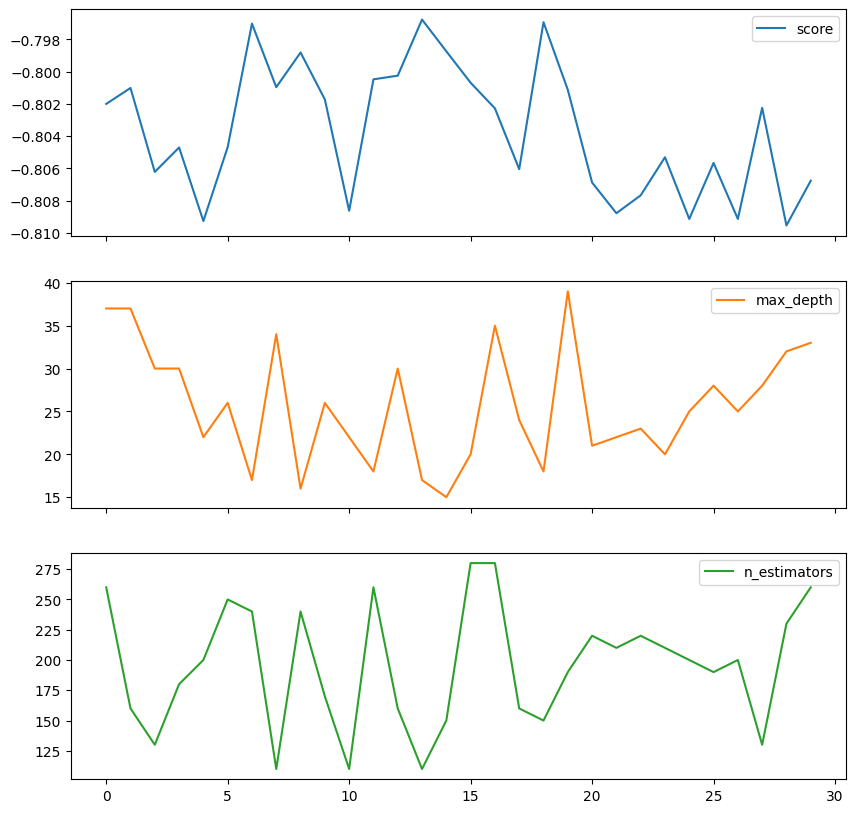

In [71]:
# отрисуем, как менялась точность при различных гиперпараметрах
tpe_results=np.array([[x['result']['loss'],
                      x['misc']['vals']['max_depth'][0],
                      x['misc']['vals']['n_estimators'][0]] for x in trials.trials])

tpe_results_df=pd.DataFrame(tpe_results,
                           columns=['score', 'max_depth', 'n_estimators'])
# тепловая карта в данном случае не очень наглядна, возьмем линейный график
tpe_results_df.plot(subplots=True,figsize=(10, 10));

In [70]:
def hyperopt_rf(params):
    model = ensemble.RandomForestClassifier(**params)
    model.fit(X, y)
    
    # Получаем метрику (например, 0.79)
    score = metrics.f1_score(y, model.predict(X))
    
    # Делаем отрицательной для минимизации
    return -score  # возвращаем -0.79